In [6]:
!pip install stable-baselines3 gymnasium numpy

In [20]:

import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from collections import deque
import warnings
warnings.filterwarnings("ignore")

class BuddyMazeEnv(gym.Env):

    def __init__(self):
        super().__init__()
        self.grid = np.array([
            [1,0,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,0,1,1,1,1],
            [1,1,1,1,1,0,1,1,1,1],
            [0,0,1,0,0,2,0,1,1,1],
            [1,1,0,1,0,1,0,0,0,1],
            [1,1,0,1,0,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,0,0,0,0],
            [1,0,0,0,0,0,1,1,1,1],
            [1,1,1,2,1,1,1,0,1,3]
        ], dtype=np.float32)

        self.rows, self.cols = 10, 10
        self.start      = (0, 0)
        self.goal       = (9, 9)
        self.actions_map = [(-1,0),(1,0),(0,-1),(0,1)]

        self.observation_space = spaces.Box(
            low  = np.array([0, 0, 0, 0],   dtype=np.float32),
            high = np.array([9, 9, 200, 500], dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(4)
        self.dist = self._bfs()

    def _bfs(self):
        dist = np.full((self.rows, self.cols), np.inf)
        dist[self.goal] = 0
        q = deque([self.goal])
        while q:
            x, y = q.popleft()
            for dx, dy in self.actions_map:
                nx, ny = x+dx, y+dy
                if 0<=nx<self.rows and 0<=ny<self.cols \
                   and self.grid[nx][ny]!=0 and dist[nx][ny]==np.inf:
                    dist[nx][ny] = dist[x][y] + 1
                    q.append((nx, ny))
        return dist

    def _obs(self):
        x, y = self.state
        return np.array([x, y, self.dist[x][y], self.steps], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state   = self.start
        self.steps   = 0
        self.visited = {}
        self.treats_collected = set()
        return self._obs(), {}

    def step(self, action):
        x, y    = self.state
        dx, dy  = self.actions_map[action]
        nx, ny  = x+dx, y+dy

        hit_wall = not (0<=nx<self.rows and 0<=ny<self.cols
                        and self.grid[nx][ny] != 0)

        if hit_wall:
            self.steps += 1
            truncated = self.steps >= 500
            return self._obs(), -5, False, truncated, {}

        self.state   = (nx, ny)
        self.steps  += 1
        self.visited[self.state] = self.visited.get(self.state, 0) + 1

        terminated = self.state == self.goal
        truncated  = self.steps >= 500

        if self.state == self.goal:
            reward = 500

        elif self.grid[nx][ny] == 2 and self.state not in self.treats_collected:
            self.treats_collected.add(self.state)
            reward = 100

        else:
            dist_before = self.dist[x][y]
            dist_after  = self.dist[nx][ny]
            reward = (dist_before - dist_after) * 3
            if self.visited.get(self.state, 0) > 1:
                reward -= 2 * self.visited[self.state]

        return self._obs(), reward, terminated, truncated, {}


class TrainCallback(BaseCallback):
    def __init__(self, print_every=20000):
        super().__init__()
        self.print_every = print_every
        self.ep_rewards  = []
        self.cur_reward  = 0
        self.successes   = 0
        self.episodes    = 0

    def _on_step(self):
        self.cur_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episodes += 1
            self.ep_rewards.append(self.cur_reward)
            if self.cur_reward >= 490:
                self.successes += 1
            self.cur_reward = 0
        if self.num_timesteps % self.print_every == 0 and self.episodes > 0:
            avg  = np.mean(self.ep_rewards[-100:])
            rate = self.successes / self.episodes * 100
            print(f"  Step {self.num_timesteps:>7} | "
                  f"Episodes: {self.episodes:>5} | "
                  f"Avg reward: {avg:>8.1f} | "
                  f"Success rate: {rate:.1f}%")
        return True


def bfs_patch(env, from_pos, to_pos):
    if from_pos == to_pos:
        return [from_pos]
    parent = {from_pos: None}
    q = deque([from_pos])
    while q:
        x, y = q.popleft()
        for dx, dy in env.actions_map:
            nx, ny = x+dx, y+dy
            if 0<=nx<env.rows and 0<=ny<env.cols \
               and env.grid[nx][ny]!=0 and (nx,ny) not in parent:
                parent[(nx,ny)] = (x, y)
                q.append((nx, ny))
                if (nx, ny) == to_pos:
                    path, node = [], to_pos
                    while node is not None:
                        path.append(node)
                        node = parent[node]
                    return list(reversed(path))
    return []

print("=" * 55)
print("  Buddy & Rover Maze — SB3 PPO")
print("=" * 55)

env = BuddyMazeEnv()
print(f"\nShortest path to Rover : {int(env.dist[env.start])} steps")
print(f"Observation space      : {env.observation_space.shape}")
print(f"Action space           : {env.action_space.n}")

model = PPO(
    "MlpPolicy", env,
    learning_rate = 5e-4,
    n_steps       = 1024,
    batch_size    = 128,
    n_epochs      = 10,
    gamma         = 0.995,
    ent_coef      = 0.01,
    verbose       = 0
)

print("\nTraining Buddy (1M steps)...\n")
model.learn(total_timesteps=1_000_000, callback=TrainCallback(print_every=20000))
print("\nTraining complete!")

print("\n" + "="*55)
print("  Finding Rover...")
print("="*55 + "\n")

best_path = None
best_len  = 9999

for attempt in range(20):
    obs, _ = env.reset()
    path   = [env.start]
    done   = False

    while not done and len(path) <= 300:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(int(action))
        path.append(env.state)
        done = terminated or truncated

    clean = [path[0]]
    for p in path[1:]:
        if p != clean[-1]:
            clean.append(p)

    if clean[-1] == env.goal:
        if len(clean) < best_len:
            best_path = clean
            best_len  = len(clean)
        print(f"  Attempt {attempt+1:>2}: SUCCESS in {len(clean)-1} steps!")
    else:
        stuck    = clean[-1]
        bfs_tail = bfs_patch(env, stuck, env.goal)
        if bfs_tail:
            patched = clean + bfs_tail[1:]
            if len(patched) < best_len:
                best_path = patched
                best_len  = len(patched)
            print(f"  Attempt {attempt+1:>2}: reached {stuck}, "
                  f"BFS patched last {len(bfs_tail)-1} steps")
        else:
            print(f"  Attempt {attempt+1:>2}: reached {stuck} — stuck")

print()

if best_path is None:
    print("Could not find a path. Run the cell again!")
else:
    treats_on_path = [p for p in best_path if env.grid[p[0]][p[1]] == 2]

    print("=" * 45)
    print("  BUDDY'S FINAL PATH TO ROVER")
    print("=" * 45)
    for i, (px, py) in enumerate(best_path):
        note = ""
        if   (px,py) == env.start:      note = "  <-- Buddy starts"
        elif (px,py) == env.goal:       note = "  <-- ROVER FOUND!"
        elif env.grid[px][py] == 2:     note = "  <-- Treat collected!"
        print(f"  Step {i:>3}: ({px}, {py}){note}")

    symbol = {0:"░", 1:".", 2:"T", 3:"R"}
    visual = [[symbol[int(env.grid[i][j])] for j in range(env.cols)]
              for i in range(env.rows)]
    for (px, py) in best_path:
        if visual[px][py] not in ["B", "R"]:
            visual[px][py] = "*"
    visual[0][0] = "B"

    print("\nMaze with Buddy's Path:\n")
    print("     " + "  ".join(str(c) for c in range(env.cols)))
    print("     " + "---" * env.cols)
    for i, row in enumerate(visual):
        print(f"  {i} | " + "  ".join(row))

    print(f"""
  =========================================
   MISSION SUMMARY
  =========================================
   Total steps   : {len(best_path)-1}
   Shortest BFS  : {int(env.dist[env.start])} steps
   Treats found  : {len(treats_on_path)} at {treats_on_path}
   Result        : Buddy found Rover!
  =========================================
    """)

  Buddy & Rover Maze — SB3 PPO

Shortest path to Rover : 40 steps
Observation space      : (4,)
Action space           : 4

Training Buddy (1M steps)...

  Step   20000 | Episodes:    40 | Avg reward:  -6252.7 | Success rate: 0.0%
  Step   40000 | Episodes:    80 | Avg reward:  -4494.8 | Success rate: 0.0%
  Step   60000 | Episodes:   120 | Avg reward:  -3114.7 | Success rate: 0.0%
  Step   80000 | Episodes:   161 | Avg reward:  -2338.6 | Success rate: 0.0%
  Step  100000 | Episodes:   219 | Avg reward:  -1786.6 | Success rate: 0.0%
  Step  120000 | Episodes:   327 | Avg reward:   -203.5 | Success rate: 0.9%
  Step  140000 | Episodes:   446 | Avg reward:   -101.1 | Success rate: 4.7%
  Step  160000 | Episodes:   547 | Avg reward:   -259.8 | Success rate: 8.0%
  Step  180000 | Episodes:   654 | Avg reward:   -228.1 | Success rate: 12.2%
  Step  200000 | Episodes:   791 | Avg reward:    -21.5 | Success rate: 19.6%
  Step  220000 | Episodes:   938 | Avg reward:     59.8 | Success rate: 26

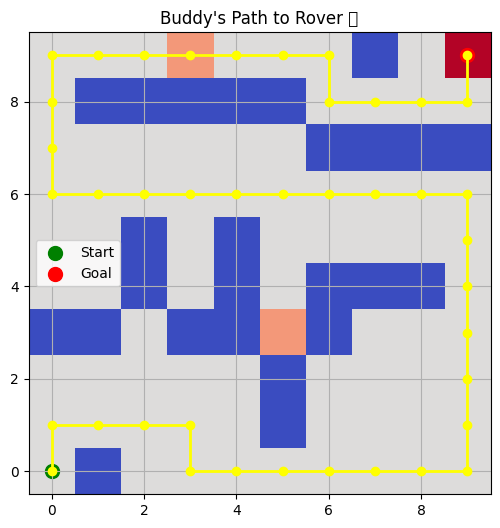

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maze(grid, path, start, goal):
    rows, cols = grid.shape
    maze_img = np.zeros((rows, cols))

    # Encode for visualization
    for i in range(rows):
        for j in range(cols):
            if grid[i][j] == 0:      # wall
                maze_img[i][j] = -1
            elif grid[i][j] == 2:    # treat
                maze_img[i][j] = 0.5
            elif grid[i][j] == 3:    # goal
                maze_img[i][j] = 1

    plt.figure(figsize=(6,6))
    plt.imshow(maze_img, cmap='coolwarm')

    # Plot path
    px = [p[1] for p in path]
    py = [p[0] for p in path]
    plt.plot(px, py, color='yellow', linewidth=2, marker='o')

    # Mark start and goal
    plt.scatter(start[1], start[0], color='green', s=100, label='Start')
    plt.scatter(goal[1], goal[0], color='red', s=100, label='Goal')

    plt.title("Buddy's Path to Rover 🐶")
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.show()


# 🔹 call this after training
plot_maze(grid, path, start, goal)